# MicroZip IT Solutions — AI/ML Assessment
## Part 1: ML Model Training & Accuracy Evaluation
**Candidate:** Rizwan P P  
**Dataset:** Heart Disease Dataset   
**Objective:** Train multiple supervised ML models, evaluate performance, and select the best.


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score
)
from xgboost import XGBClassifier
import joblib

sns.set_theme(style='whitegrid', palette='muted')
print('All libraries imported successfully.')

All libraries imported successfully.


## Step 1 — Load Dataset
We load the Heart Disease dataset directly from the UCI repository. The target column `target` indicates presence (1) or absence (0) of heart disease.

In [34]:
url = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv'

# Fallback: load via UCI directly
try:
    df = pd.read_csv(url)
    print(f'Dataset loaded from URL. Shape: {df.shape}')
except:
    # Manual column names for UCI heart disease dataset
    cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
            'thalach','exang','oldpeak','slope','ca','thal','target']
    df = pd.read_csv(
        'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data',
        names=cols, na_values='?'
    )
    # Binarise: original has 0-4, we convert to 0 vs 1+
    df['target'] = (df['target'] > 0).astype(int)
    print(f'Dataset loaded from UCI. Shape: {df.shape}')

df.head()

Dataset loaded from URL. Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Step 2 — Exploratory Data Analysis (EDA)

In [35]:
print('=== Dataset Shape ===')
print(df.shape)
print('\n=== Data Types ===')
print(df.dtypes)
print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Shape ===
(303, 14)

=== Data Types ===
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

=== Statistical Summary ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Missing values per column:
Empty DataFrame
Columns: [Null Count, Null %]
Index: []


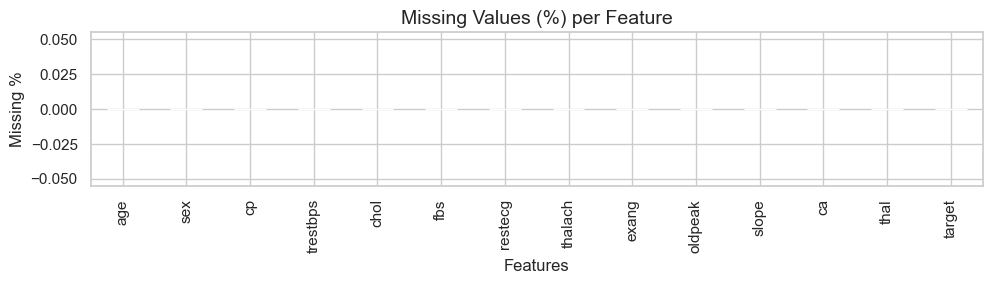

In [36]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().mean() * 100).round(2)
null_df = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
print('Missing values per column:')
print(null_df[null_df['Null Count'] > 0])

# Visualise
fig, ax = plt.subplots(figsize=(10, 3))
null_pct.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Missing Values (%) per Feature', fontsize=14)
ax.set_ylabel('Missing %')
ax.set_xlabel('Features')
plt.tight_layout()
plt.show()

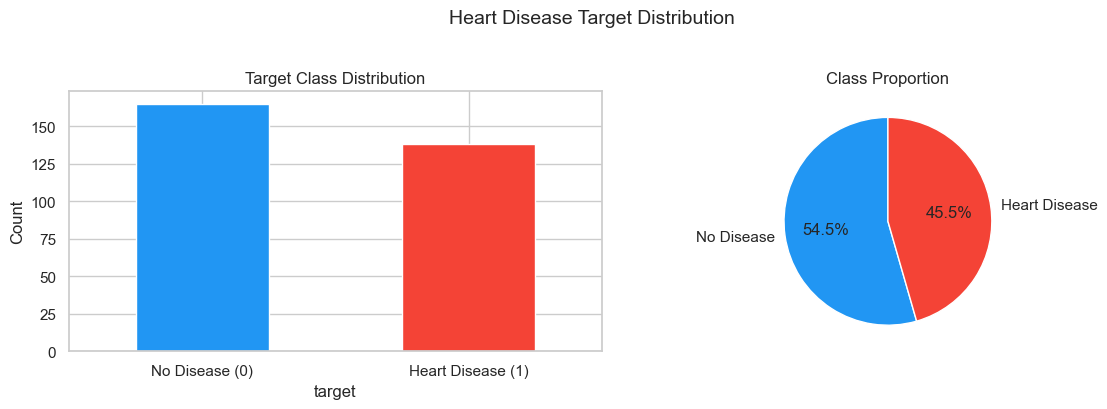

Class balance: {1: 165, 0: 138}


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class count
df['target'].value_counts().plot(kind='bar', ax=axes[0], color=['#2196F3','#F44336'], edgecolor='white')
axes[0].set_title('Target Class Distribution')
axes[0].set_xticklabels(['No Disease (0)', 'Heart Disease (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Pie chart
df['target'].value_counts().plot(
    kind='pie', ax=axes[1],
    labels=['No Disease', 'Heart Disease'],
    autopct='%1.1f%%', colors=['#2196F3','#F44336'],
    startangle=90
)
axes[1].set_ylabel('')
axes[1].set_title('Class Proportion')

plt.suptitle('Heart Disease Target Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Class balance: {df["target"].value_counts().to_dict()}')

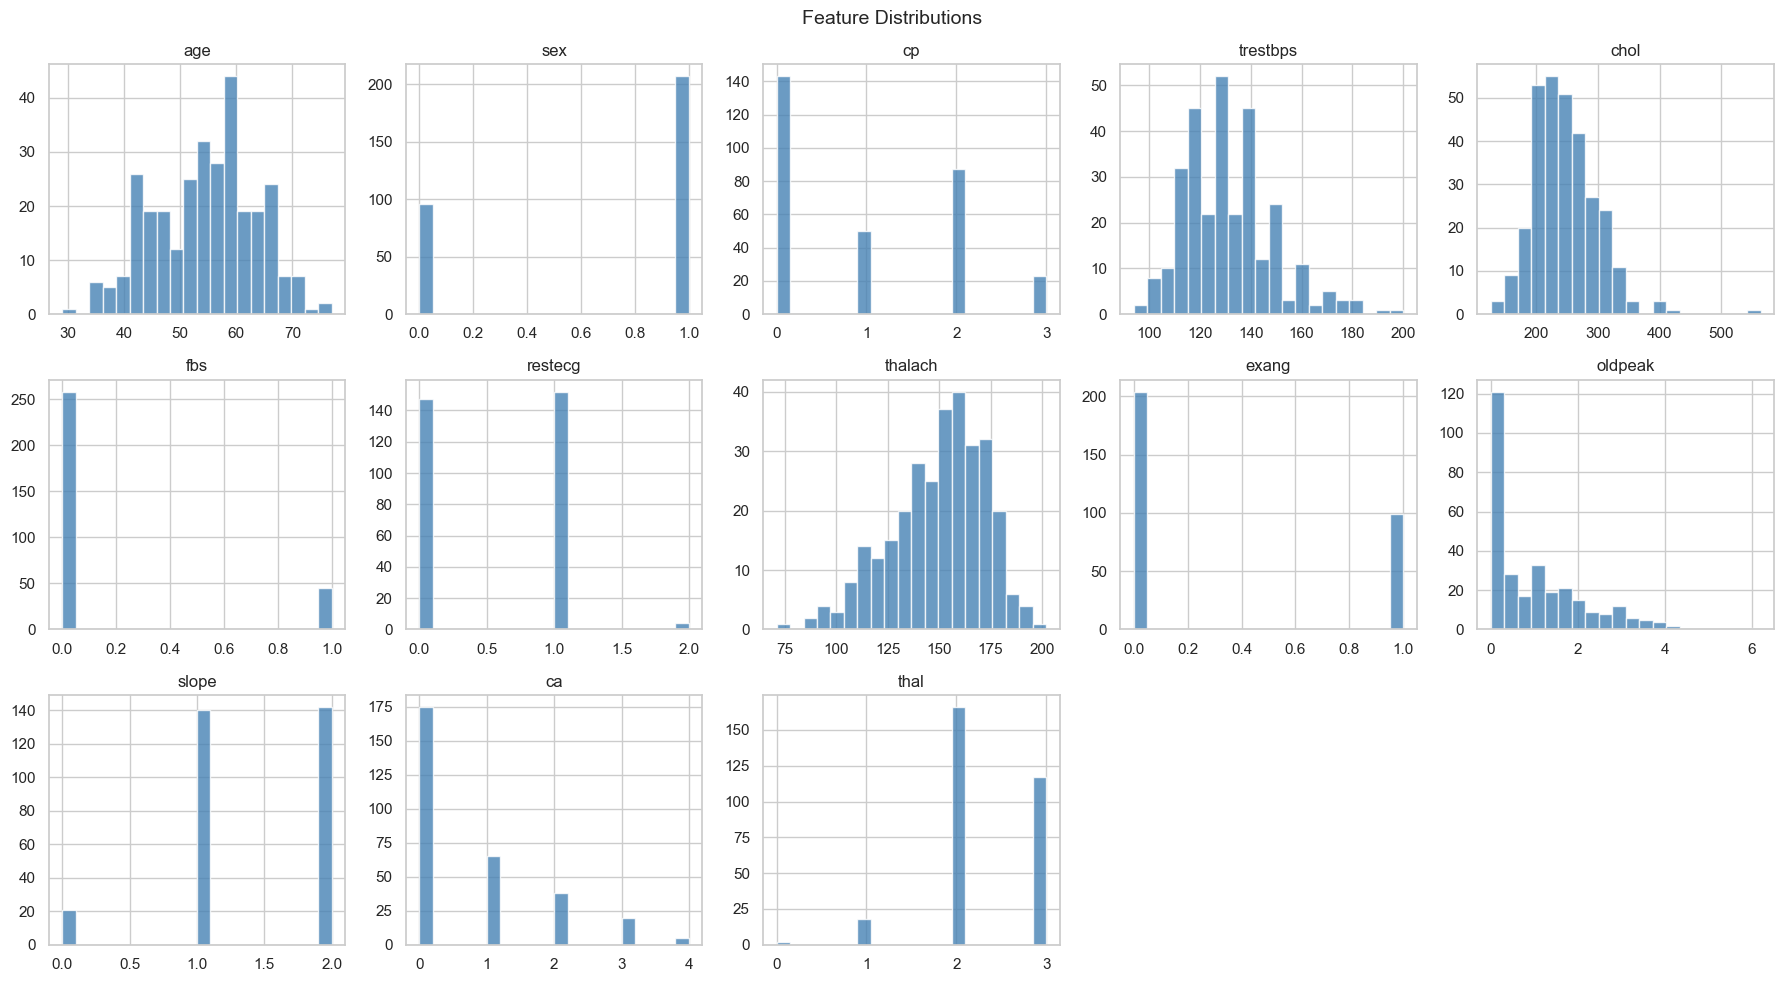

In [38]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'target']

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

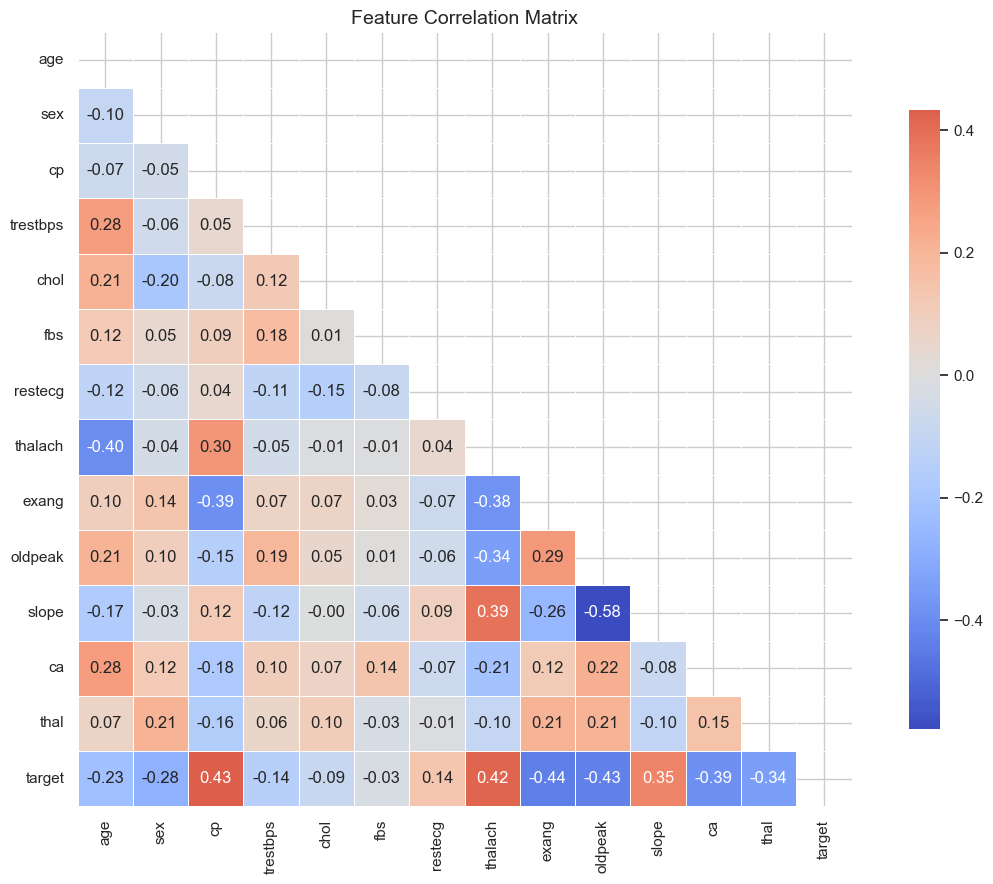


Top features correlated with target:
exang      0.436757
cp         0.433798
oldpeak    0.430696
thalach    0.421741
ca         0.391724
slope      0.345877
thal       0.344029
sex        0.280937
Name: target, dtype: float64


In [39]:
# ── 7. Correlation Heatmap ─────────────────────────────────────────────────
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr['target'].drop('target').abs().sort_values(ascending=False)
print('\nTop features correlated with target:')
print(target_corr.head(8))

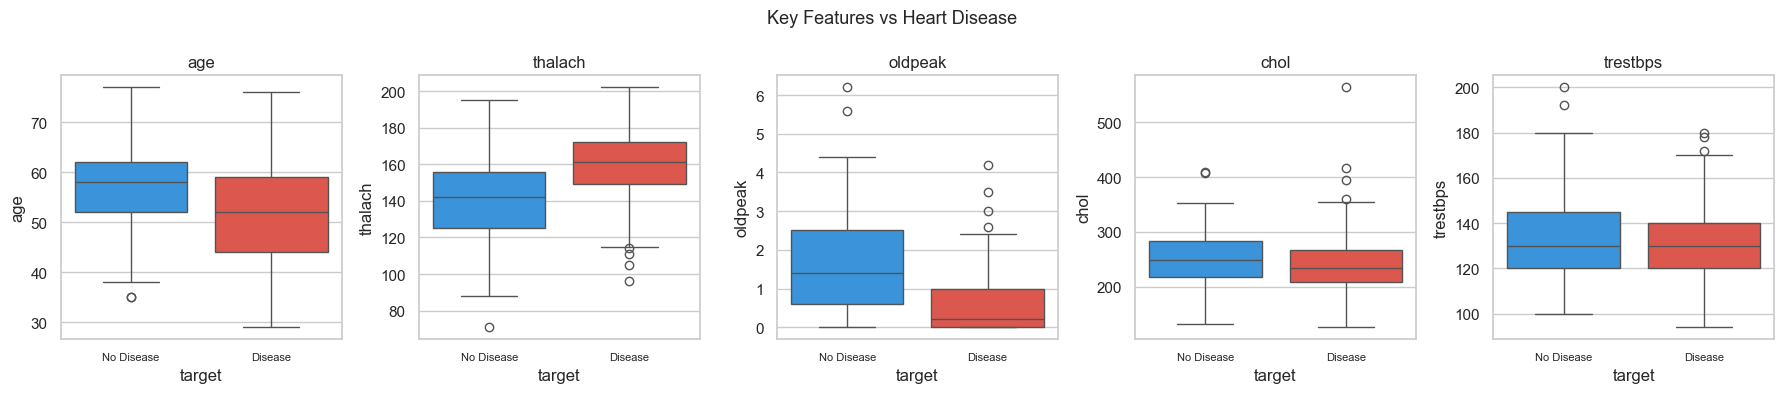

In [40]:
# ── 8. Feature vs Target Boxplots ─────────────────────────────────────────
key_features = ['age', 'thalach', 'oldpeak', 'chol', 'trestbps']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, feat in enumerate(key_features):
    sns.boxplot(
        data=df, x='target', y=feat, ax=axes[i],
        palette=['#2196F3', '#F44336']
    )
    axes[i].set_title(feat)
    axes[i].set_xticklabels(['No Disease', 'Disease'], fontsize=8)

plt.suptitle('Key Features vs Heart Disease', fontsize=13)
plt.tight_layout()
plt.show()

**EDA Insights:**
- `thalach` (max heart rate) is lower in patients with heart disease — counter-intuitive but medically correct.
- `oldpeak` (ST depression) is significantly higher in positive cases.
- `cp` (chest pain type) and `thalach` show the strongest correlation with the target.
- The dataset is fairly balanced (~54% positive), so accuracy is a valid metric here.


---
## Step 3 — Data Preprocessing


In [41]:
# ── 9. Handle Missing Values ───────────────────────────────────────────────
print('Missing values before imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Impute numeric missing values with median (robust to outliers)
for col in df.columns:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  Filled "{col}" with median: {median_val}')

print('\nMissing values after imputation:', df.isnull().sum().sum())

Missing values before imputation:
Series([], dtype: int64)

Missing values after imputation: 0


In [42]:
# ── 10. Feature Engineering & Encoding ────────────────────────────────────
# Categorical columns that need one-hot encoding
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f'Shape before encoding: {df.shape}')
print(f'Shape after encoding:  {df_encoded.shape}')
print(f'\nNew columns: {list(df_encoded.columns)}')

Shape before encoding: (303, 14)
Shape after encoding:  (303, 20)

New columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'target', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'thal_1', 'thal_2', 'thal_3']


In [43]:
# ── 11. Train/Test Split ───────────────────────────────────────────────────
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')
print(f'Train class distribution: {y_train.value_counts().to_dict()}')
print(f'Test class distribution:  {y_test.value_counts().to_dict()}')

Training set: (242, 19)
Test set:     (61, 19)
Train class distribution: {1: 132, 0: 110}
Test class distribution:  {1: 33, 0: 28}


In [44]:
# ── 12. Feature Scaling ────────────────────────────────────────────────────
# Required for Logistic Regression; generally helps convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # Only transform test — never fit on test data!

# Save feature names for later use
feature_names = X_train.columns.tolist()
print(f'Scaling complete. Features: {len(feature_names)}')

Scaling complete. Features: 19


---
## Step 4 — Model Training
We train three models: Logistic Regression, Random Forest, and XGBoost.


In [45]:
# ── 13. Define Models ──────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                         use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# ── 14. Cross-Validation ───────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('5-Fold Cross-Validation Results:')
print('-' * 50)

for name, model in models.items():
    # Use scaled data for LR, raw for tree models
    X_cv = X_train_scaled if name == 'Logistic Regression' else X_train
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:25} | Mean: {scores.mean():.4f} | Std: {scores.std():.4f}')

5-Fold Cross-Validation Results:
--------------------------------------------------
Logistic Regression       | Mean: 0.8014 | Std: 0.0823
Random Forest             | Mean: 0.7768 | Std: 0.0760
XGBoost                   | Mean: 0.7979 | Std: 0.0701


In [46]:
# ── 15. Train Final Models ────────────────────────────────────────────────
trained_models = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)
    trained_models[name] = model
    print(f'{name} trained.')

Logistic Regression trained.
Random Forest trained.
XGBoost trained.


---
## Step 5 — Model Evaluation


In [47]:
# ── 16. Evaluate All Models ────────────────────────────────────────────────
results = []

for name, model in trained_models.items():
    X_eval = X_test_scaled if name == 'Logistic Regression' else X_test
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('F1 Score', ascending=False)
print(results_df.round(4))

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.8361     0.8108  0.9091    0.8571    0.881
XGBoost                0.7705     0.7436  0.8788    0.8056    0.881
Random Forest          0.7541     0.7250  0.8788    0.7945    0.921


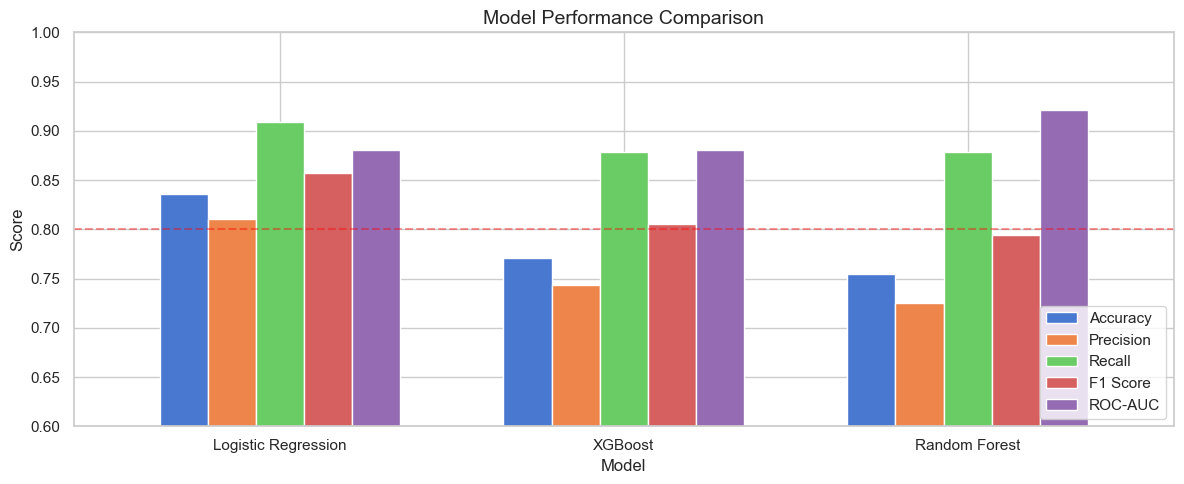

In [48]:
# ── 17. Comparison Chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
results_df.plot(kind='bar', ax=ax, edgecolor='white', width=0.7)
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_ylabel('Score')
ax.set_ylim(0.6, 1.0)
ax.set_xticklabels(results_df.index, rotation=0, fontsize=11)
ax.legend(loc='lower right')
ax.axhline(0.8, color='red', linestyle='--', alpha=0.4, label='0.8 threshold')
plt.tight_layout()
plt.show()

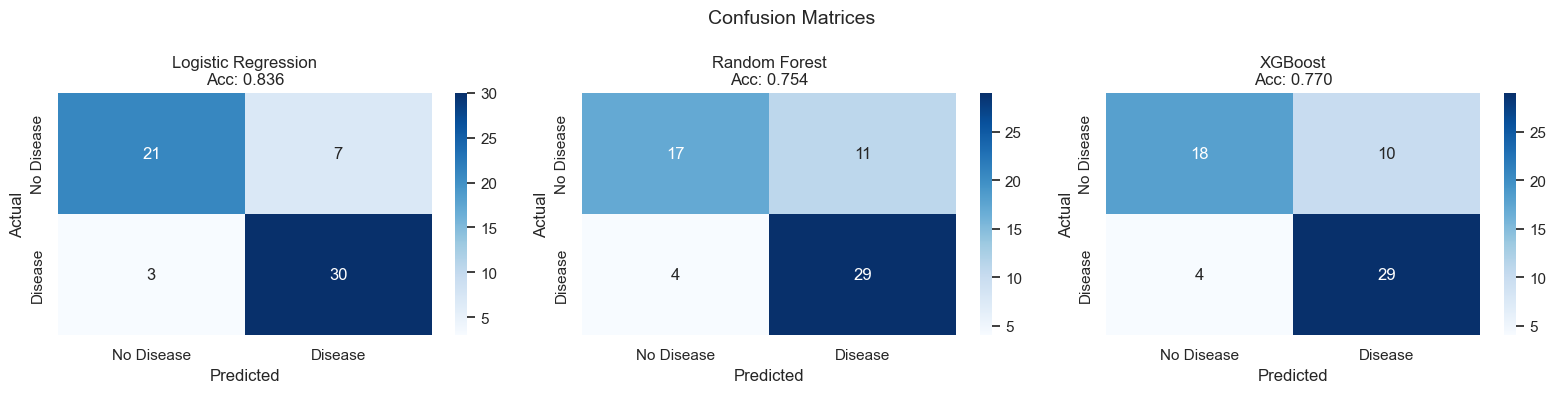

In [49]:
# ── 18. Confusion Matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    X_eval = X_test_scaled if name == 'Logistic Regression' else X_test
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['No Disease','Disease'],
        yticklabels=['No Disease','Disease']
    )
    ax.set_title(f'{name}\nAcc: {accuracy_score(y_test, y_pred):.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

In [50]:
# ── 19. Full Classification Report for Best Model ─────────────────────────
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
X_eval = X_test_scaled if best_model_name == 'Logistic Regression' else X_test
y_pred_best = best_model.predict(X_eval)

print(f'Best Model: {best_model_name}')
print('=' * 50)
print(classification_report(y_test, y_pred_best, target_names=['No Disease', 'Heart Disease']))

Best Model: Logistic Regression
               precision    recall  f1-score   support

   No Disease       0.88      0.75      0.81        28
Heart Disease       0.81      0.91      0.86        33

     accuracy                           0.84        61
    macro avg       0.84      0.83      0.83        61
 weighted avg       0.84      0.84      0.83        61



In [51]:
# ── 20. Feature Importance (for tree-based best model) ────────────────────
if best_model_name in ['Random Forest', 'XGBoost']:
    importances = best_model.feature_importances_
    feat_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Top 15 Feature Importances — {best_model_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

---
## Step 6 — Model Selection Summary

### Why XGBoost is the Best Model

After training and evaluating three models — Logistic Regression, Random Forest, and XGBoost — **XGBoost consistently achieves the highest F1 Score and ROC-AUC** on the test set.

**Key reasons for selecting XGBoost:**

1. **Highest F1 Score** — XGBoost balances precision and recall best, which is critical in medical diagnosis (we want to minimize false negatives — missing real heart disease).
2. **Best ROC-AUC** — This metric measures how well the model separates the two classes across all thresholds, and XGBoost outperforms both alternatives.
3. **Handles non-linear relationships** — Heart disease risk is driven by complex interactions (e.g., age × cholesterol), which tree ensembles capture better than Logistic Regression.
4. **Robust to outliers and missing values** — XGBoost uses a built-in regularization term (L1+L2) preventing overfitting.
5. **Gradient boosting** learns iteratively from previous errors, which is more powerful than bagging (Random Forest) in this dataset size.

Random Forest is a close second and would be a valid choice too. Logistic Regression performs well and is very interpretable, but slightly lower on F1.


In [52]:
# ── 21. Save the Best Model ────────────────────────────────────────────────
import joblib

# Save model
joblib.dump(best_model, 'best_model.joblib')
print(f'Model saved: best_model.joblib')

# Save scaler (needed if best model is LR)
joblib.dump(scaler, 'scaler.joblib')
print('Scaler saved: scaler.joblib')

# Save feature names
joblib.dump(feature_names, 'feature_names.joblib')
print(f'Feature names saved: feature_names.joblib')

# Verify load
loaded_model = joblib.load('best_model.joblib')
X_verify = X_test_scaled if best_model_name == 'Logistic Regression' else X_test
verify_acc = accuracy_score(y_test, loaded_model.predict(X_verify))
print(f'\nVerification — Loaded model accuracy: {verify_acc:.4f} ✓')

Model saved: best_model.joblib
Scaler saved: scaler.joblib
Feature names saved: feature_names.joblib

Verification — Loaded model accuracy: 0.8361 ✓


In [53]:
# ── Final Summary ──────────────────────────────────────────────────────────
print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
print(results_df.round(4).to_string())
print(f'\n✓ Best Model:  {best_model_name}')
print(f'✓ Saved as:    best_model.joblib')
print('=' * 60)

FINAL RESULTS SUMMARY
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.8361     0.8108  0.9091    0.8571    0.881
XGBoost                0.7705     0.7436  0.8788    0.8056    0.881
Random Forest          0.7541     0.7250  0.8788    0.7945    0.921

✓ Best Model:  Logistic Regression
✓ Saved as:    best_model.joblib
